In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve
from sklearn.preprocessing import LabelEncoder

In [2]:
# --- 1. Data Exploration ---
train_df = pd.read_csv('Titanic_train.csv')

print("Summary Statistics:")
print(train_df.describe())

Summary Statistics:
       PassengerId    Survived      Pclass         Age       SibSp  \
count   891.000000  891.000000  891.000000  714.000000  891.000000   
mean    446.000000    0.383838    2.308642   29.699118    0.523008   
std     257.353842    0.486592    0.836071   14.526497    1.102743   
min       1.000000    0.000000    1.000000    0.420000    0.000000   
25%     223.500000    0.000000    2.000000   20.125000    0.000000   
50%     446.000000    0.000000    3.000000   28.000000    0.000000   
75%     668.500000    1.000000    3.000000   38.000000    1.000000   
max     891.000000    1.000000    3.000000   80.000000    8.000000   

            Parch        Fare  
count  891.000000  891.000000  
mean     0.381594   32.204208  
std      0.806057   49.693429  
min      0.000000    0.000000  
25%      0.000000    7.910400  
50%      0.000000   14.454200  
75%      0.000000   31.000000  
max      6.000000  512.329200  


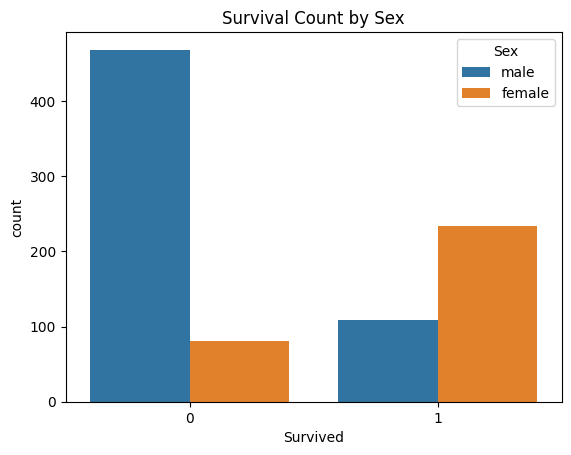

In [3]:
# Visualization: Survival by Sex
sns.countplot(x='Survived', hue='Sex', data=train_df)
plt.title('Survival Count by Sex')
plt.show()

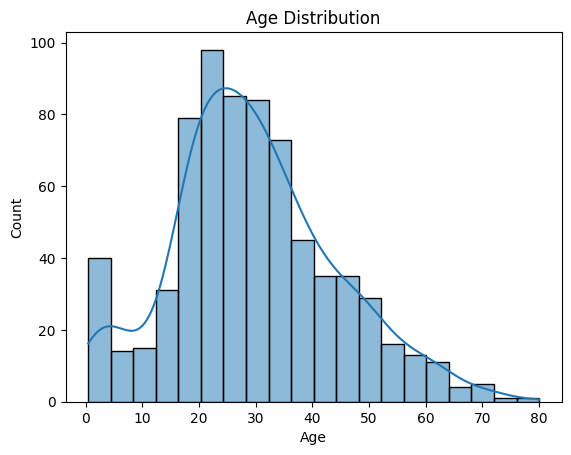

In [4]:
# Visualization: Age Distribution
sns.histplot(train_df['Age'].dropna(), kde=True)
plt.title('Age Distribution')
plt.show()

In [5]:
# Handling missing values
train_df['Age'] = train_df['Age'].fillna(train_df['Age'].median())
train_df['Embarked'] = train_df['Embarked'].fillna(train_df['Embarked'].mode()[0])

In [6]:
# Dropping unnecessary columns
df = train_df.drop(['Cabin', 'Name', 'Ticket', 'PassengerId'], axis=1)

In [7]:
# Encoding categorical variables
le = LabelEncoder()
df['Sex'] = le.fit_transform(df['Sex']) # male: 1, female: 0
df = pd.get_dummies(df, columns=['Embarked'], drop_first=True)

In [8]:
# --- 3. Model Building ---
X = df.drop('Survived', axis=1)
y = df['Survived']

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [9]:
# Save the model for Streamlit deployment
with open('titanic_model.pkl', 'wb') as f:
    pickle.dump(model, f)

In [10]:
# --- 4. Model Evaluation ---
y_pred = model.predict(X_val)
y_prob = model.predict_proba(X_val)[:, 1]

print("\nEvaluation Metrics:")
print(f"Accuracy: {accuracy_score(y_val, y_pred):.4f}")
print(f"Precision: {precision_score(y_val, y_pred):.4f}")
print(f"Recall: {recall_score(y_val, y_pred):.4f}")
print(f"F1-Score: {f1_score(y_val, y_pred):.4f}")
print(f"ROC-AUC Score: {roc_auc_score(y_val, y_prob):.4f}")


Evaluation Metrics:
Accuracy: 0.8101
Precision: 0.7857
Recall: 0.7432
F1-Score: 0.7639
ROC-AUC Score: 0.8828


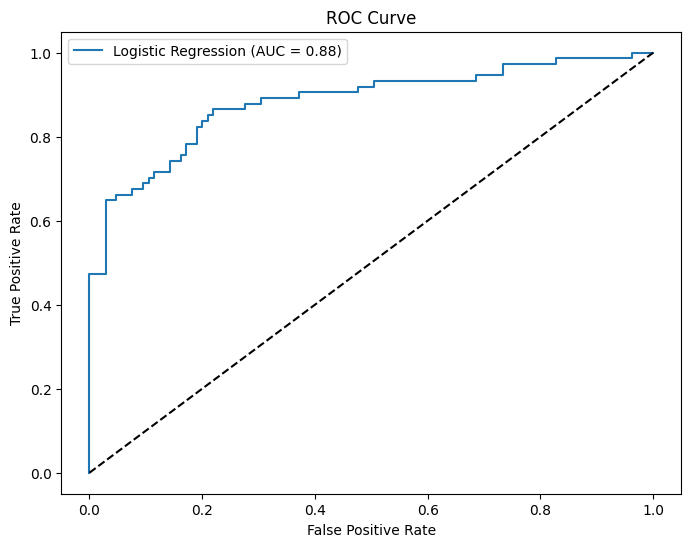

In [11]:
# ROC Curve Visualization
fpr, tpr, _ = roc_curve(y_val, y_prob)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'Logistic Regression (AUC = {roc_auc_score(y_val, y_prob):.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

In [12]:
# --- 5. Interpretation ---
coef_df = pd.DataFrame({'Feature': X.columns, 'Coefficient': model.coef_[0]})
print("\nModel Coefficients:")
print(coef_df.sort_values(by='Coefficient', ascending=False))


Model Coefficients:
      Feature  Coefficient
5        Fare     0.002570
2         Age    -0.030592
4       Parch    -0.108025
6  Embarked_Q    -0.112181
3       SibSp    -0.294975
7  Embarked_S    -0.401270
0      Pclass    -0.938550
1         Sex    -2.590612


In [13]:
with open('titanic_model.pkl', 'wb') as f:
    pickle.dump(model, f)